In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('/content/cleaned_dataset.csv')

In [4]:
df['CouponCode'] = df['CouponCode'].fillna('No Coupon')
df['Date'] = pd.to_datetime(df['Date'])
df['Quantity'] = df['Quantity'].astype(np.int32)
df['ItemsInCart'] = df['ItemsInCart'].astype(np.int32)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int32         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int32         
 11  CouponCode       1200 non-null   object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int32(

## Descriptive Statistics —

Descriptive statistics are the foundational techniques used in data science to summarize, organize, and interpret the main features of a dataset
- Mean
- Median
- Mode
- Standard Deviation
- Skewness


> **Key insight:** If mean >> median, the data is *right-skewed* (pulled up by high values).  
> If mean << median, the data is *left-skewed*.



In [6]:
numeric_cols = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']
ds_df = df[numeric_cols].describe().round(2)

In [7]:
ds_df.loc['median'] = df[numeric_cols].median().round(2)
ds_df.loc['Skewness'] = df[numeric_cols].skew().round(2)
print("Descriptive statistics")
ds_df

Descriptive statistics


,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.00,1200.00,1200.00,1200.00
mean,2.95,356.41,5.48,1053.97
std,1.41,197.18,2.28,819.86
min,1.00,11.39,1.00,11.39
25%,2.00,186.06,4.00,410.52
50%,3.00,364.21,5.00,823.62
75%,4.00,521.57,7.00,1578.48
max,5.00,699.93,10.00,3456.40
median,3.00,364.21,5.00,823.62
Skewness,0.03,-0.03,0.00,0.89



## Univariate Analysis —
Univariate analysis is the simplest form of statistical analysis, focusing entirely on a single variable (a single column of data) at a time

Depending on the data type, different graphs are used to visualize the distribution


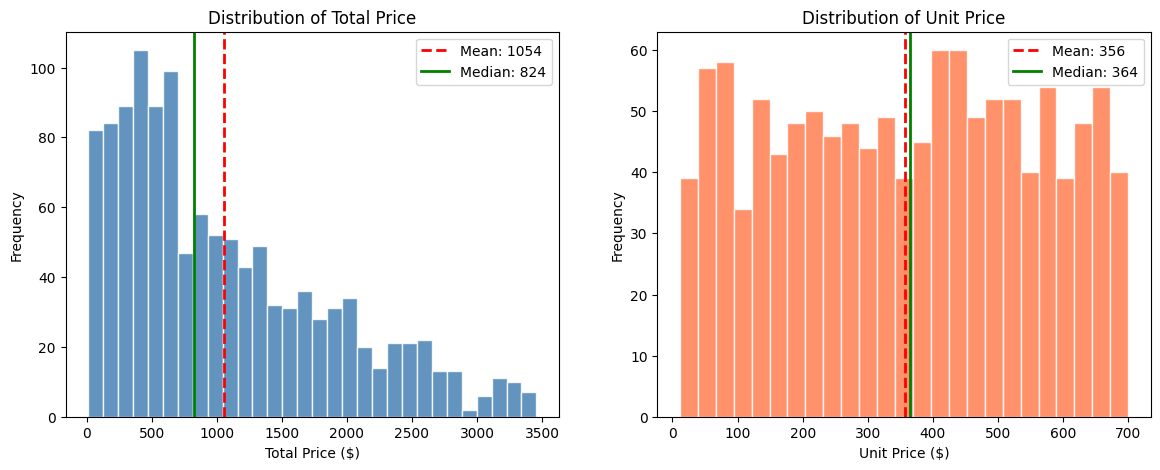

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# TotalPrice distribution
axes[0].hist(df['TotalPrice'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['TotalPrice'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df['TotalPrice'].mean():.0f}")
axes[0].axvline(df['TotalPrice'].median(), color='green', linestyle='-', linewidth=2, label=f"Median: {df['TotalPrice'].median():.0f}")
axes[0].set_title('Distribution of Total Price')
axes[0].set_xlabel('Total Price ($)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# UnitPrice distribution
axes[1].hist(df['UnitPrice'], bins=25, color='coral', edgecolor='white', alpha=0.85)
axes[1].axvline(df['UnitPrice'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df['UnitPrice'].mean():.0f}")
axes[1].axvline(df['UnitPrice'].median(), color='green', linestyle='-', linewidth=2, label=f"Median: {df['UnitPrice'].median():.0f}")
axes[1].set_title('Distribution of Unit Price')
axes[1].set_xlabel('Unit Price ($)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.show()

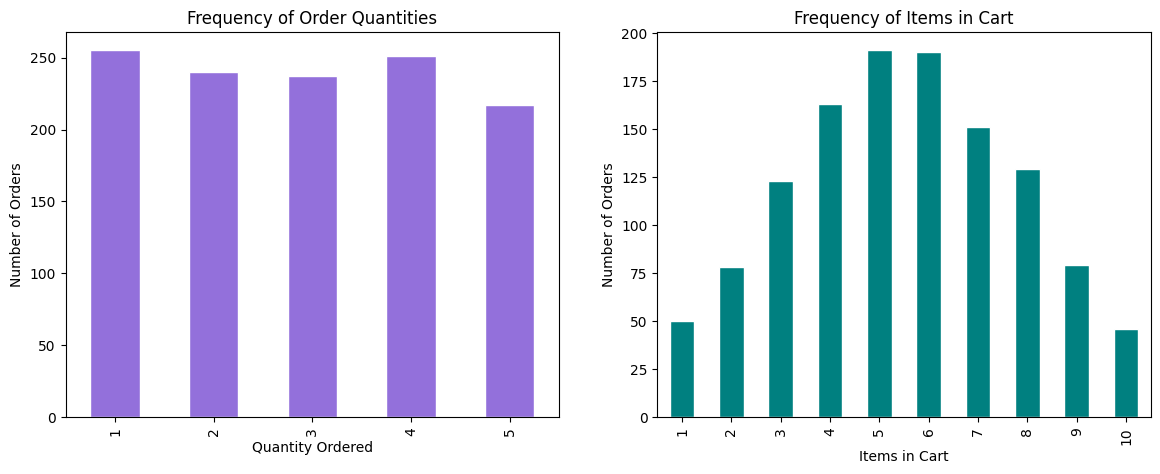

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['Quantity'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='mediumpurple', edgecolor='white')
axes[0].set_title('Frequency of Order Quantities')
axes[0].set_xlabel('Quantity Ordered')
axes[0].set_ylabel('Number of Orders')

df['ItemsInCart'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='teal', edgecolor='white')
axes[1].set_title('Frequency of Items in Cart')
axes[1].set_xlabel('Items in Cart')
axes[1].set_ylabel('Number of Orders')

plt.show()

## Bivariate & Categorical Analysis <a id='6-bivariate'></a>

Now we compare variables against each other — asking *"What drives revenue?"*

### Questions we investigate:
1. Which **product** generates the most total revenue?
2. Which **payment method** is most popular?
3. are many orders cancelled or returned?
4. Which **referral source** brings the most customers?

In [10]:
# 1 Which product generates the most total revenue?
temp_df = df.groupby([df['Product'], df['OrderStatus']]).agg({'Quantity':'sum', 'TotalPrice':'sum'}).reset_index()

In [11]:
temp_1 = temp_df[(temp_df['OrderStatus'] != 'Cancelled') & (temp_df['OrderStatus'] != 'Returned')].groupby(temp_df['Product']).agg({'TotalPrice':'sum'})
sorted_temp_1 = temp_1.sort_values(by='TotalPrice', ascending=False)

Text(0, 0.5, 'Sales')

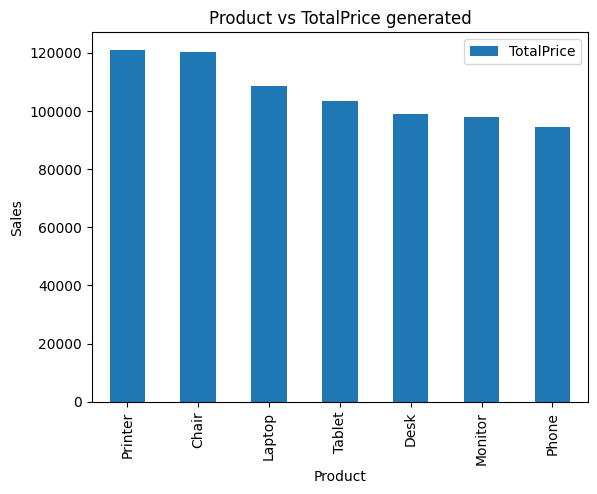

In [12]:
fig , ax = plt.subplots()
sorted_temp_1.plot(kind='bar', ax=ax, title='Product vs TotalPrice generated')
ax.set_xlabel("Product")
ax.set_ylabel("Sales")

In [13]:
# Which payment method is most popular?

Text(0, 0.5, 'Times Used ')

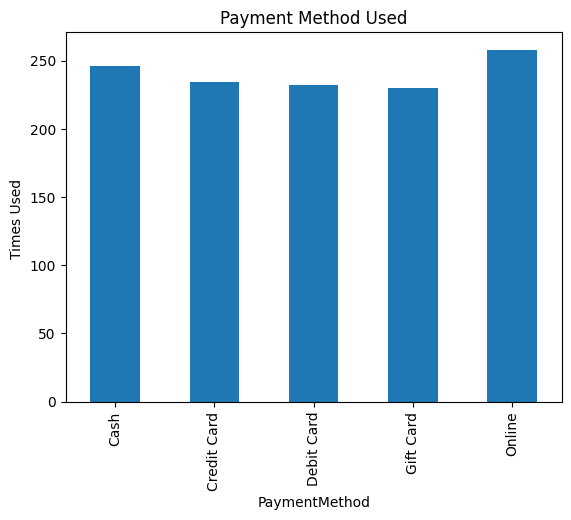

In [14]:
payment_method = df.groupby(df['PaymentMethod']).size()
fig , ax = plt.subplots()
payment_method.plot(kind='bar', ax=ax, title='Payment Method Used')
ax.set_xlabel("PaymentMethod")
ax.set_ylabel("Times Used ")

In [15]:
# are many orders cancelled or returned?

In [16]:
PO_status = temp_df.pivot_table(values='Quantity', index='Product', columns='OrderStatus')

Text(0, 0.5, 'Quantity')

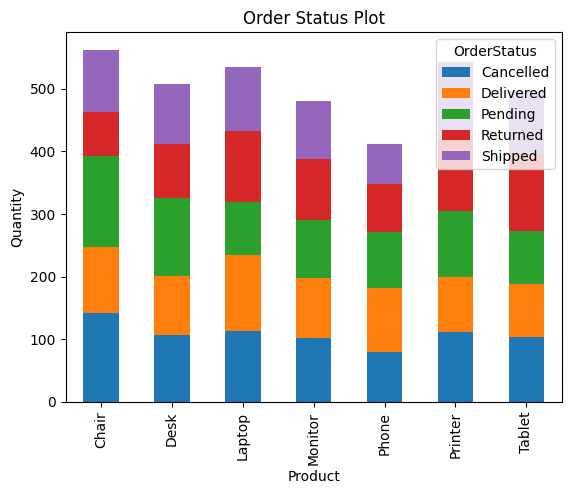

In [17]:
PO_status.plot(kind='bar', stacked=True, title='Order Status Plot')
plt.ylabel("Quantity")

In [18]:
PO_status = temp_df.pivot_table(values='Quantity', index='OrderStatus', columns='Product')

In [69]:
PO_status.sample(5)

Product,Chair,Desk,Laptop,Monitor,Phone,Printer,Tablet
OrderStatus,,,,,,,
Returned,71.0,86.0,114.0,97.0,77.0,114.0,123.0
Cancelled,142.0,107.0,113.0,102.0,80.0,112.0,103.0
Delivered,105.0,94.0,121.0,96.0,101.0,88.0,85.0
Shipped,99.0,97.0,102.0,93.0,63.0,124.0,102.0
Pending,145.0,124.0,85.0,92.0,90.0,104.0,84.0


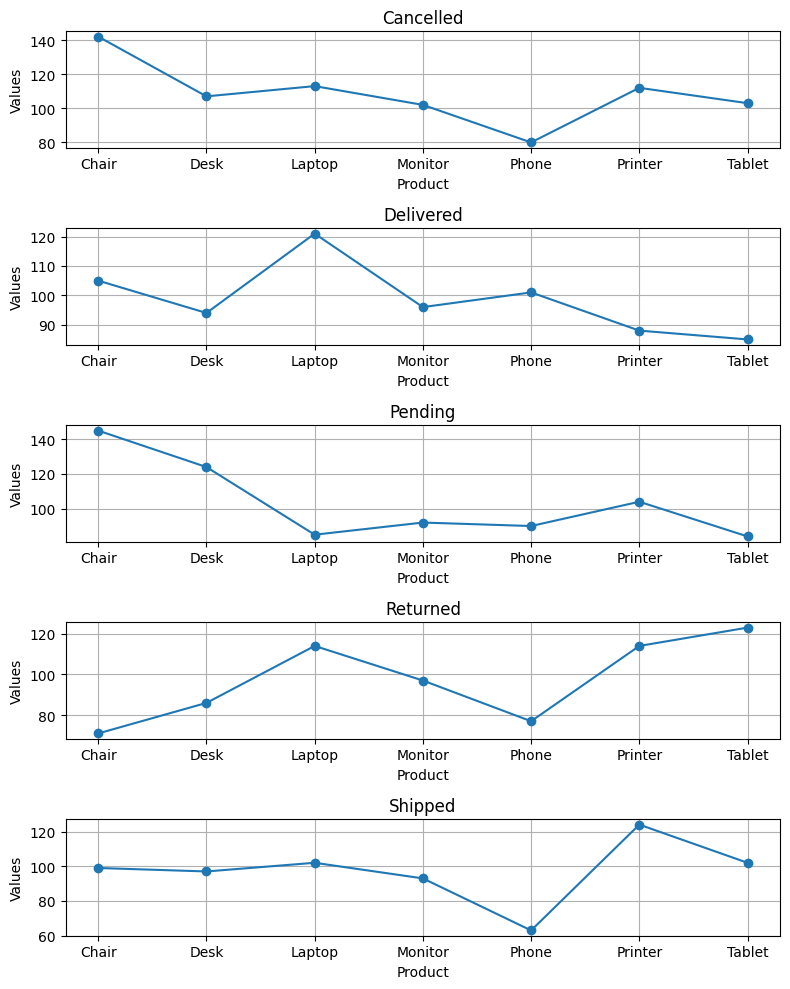

In [73]:
fig, ax = plt.subplots(len(PO_status), 1, figsize=(8, 2*len(PO_status)))
if len(PO_status) == 1:
    ax = [ax]

for i, (index, row) in enumerate(PO_status.iterrows()):
    ax[i].plot(PO_status.columns, row.values, marker='o')
    ax[i].set_title(index)
    ax[i].set_xlabel("Product")
    ax[i].set_ylabel("Values")
    ax[i].grid(True)

plt.tight_layout()
plt.show()

In [20]:
# Which referral source brings the most customers?

In [21]:
referal_source_df = df.groupby(df['ReferralSource']).size()


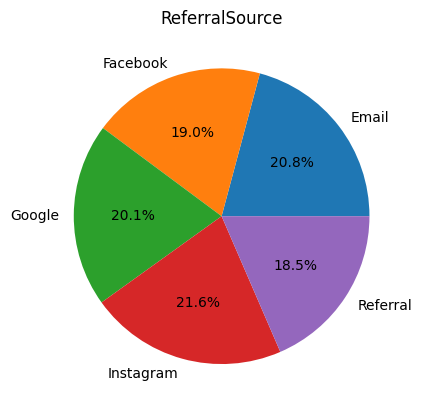

In [22]:
plt.pie(referal_source_df.values, autopct='%0.1f%%',labels=referal_source_df.index )
plt.title("ReferralSource")
plt.show()

## Trend Analysis — Sales Over Time <a id='7-trend'></a>

Trend analysis reveals whether the business is growing, shrinking, or seasonal.  
We look at:
- **Monthly revenue trend**
- **Revenue by year** — year-over-year comparison

In [ ]:
# Revenue by year — year-over-year comparison

In [34]:
df['month'] = df['Date'].dt.month
df['year'] = df['Date'].dt.year
df['yearMonth'] = df['year'].astype(str) + '-' + df['month'].astype(str).str.zfill(2)

In [50]:
month_wise_data = df.groupby(df['yearMonth']).agg({'TotalPrice':'sum'}).reset_index()

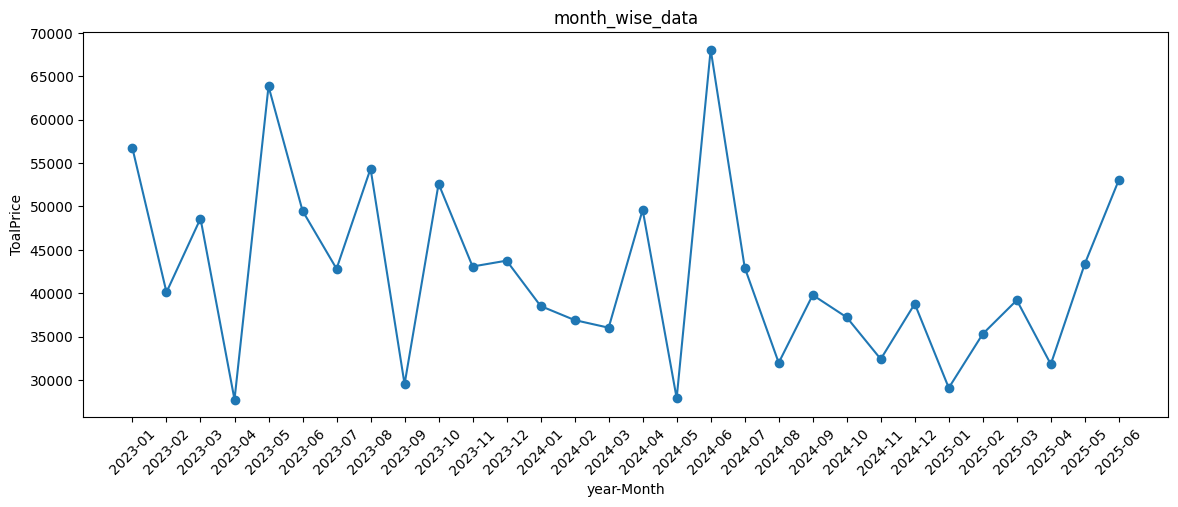

In [51]:
from matplotlib.typing import MarkerType
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(month_wise_data['yearMonth'], month_wise_data['TotalPrice'], marker='o')
ax.set_title("month_wise_data")
ax.set_xlabel('year-Month')
ax.set_ylabel('ToalPrice')
ax.tick_params(axis='x', rotation=45)

In [ ]:
# Monthly revenue trend

In [53]:
year_wise_data = df.groupby(df['year']).agg({'TotalPrice':'sum'}).reset_index()

Text(0, 0.5, 'TotalPrice')

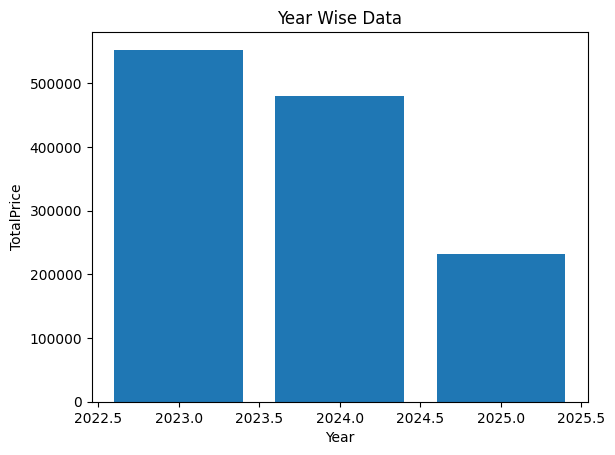

In [56]:
fig, ax = plt.subplots()
ax.bar(year_wise_data['year'], year_wise_data['TotalPrice'])
ax.set_title('Year Wise Data')
ax.set_xlabel('Year')
ax.set_ylabel('TotalPrice')

## Outlier Detection — IQR Method <a id='8-outliers'></a>

### What is an outlier?
An outlier is a data point that lies far outside the normal range of the data.

### The IQR Method (Interquartile Range)
This is the most robust method for business data (not sensitive to extreme values):

```
IQR = Q3 − Q1
Lower Bound = Q1 − 1.5 × IQR
Upper Bound = Q3 + 1.5 × IQR
```

Any value outside these bounds is flagged as a **suspect**.

### Noise vs. Signal
- **Noise (Error):** Data entry mistakes, typos → *Clean / Remove*
- **Signal (Insight):** VIP customers, bulk orders, fraud signals → *Investigate*

Text(0.5, 0.98, 'Boxplots — Outlier Detection')

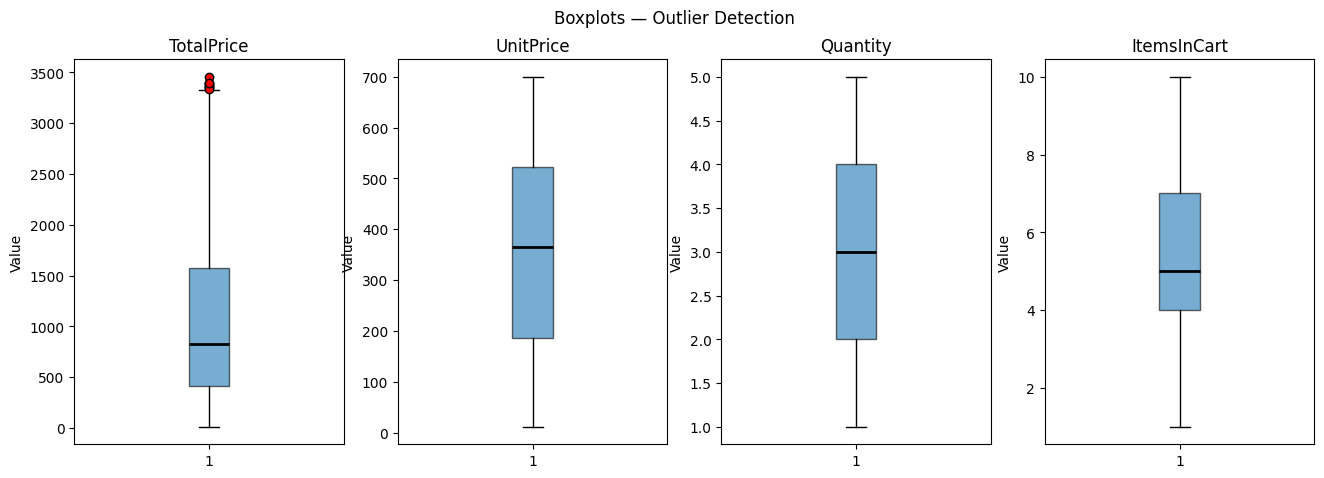

In [62]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
cols = ['TotalPrice', 'UnitPrice', 'Quantity', 'ItemsInCart']

for ax, col in zip(axes, cols):
    ax.boxplot(df[col].dropna(), patch_artist=True, boxprops=dict( alpha=0.6), medianprops=dict(color='black', linewidth=2),
               flierprops=dict(marker='o', markerfacecolor='red'))
    ax.set_title(col)
    ax.set_ylabel('Value')

plt.suptitle('Boxplots — Outlier Detection')

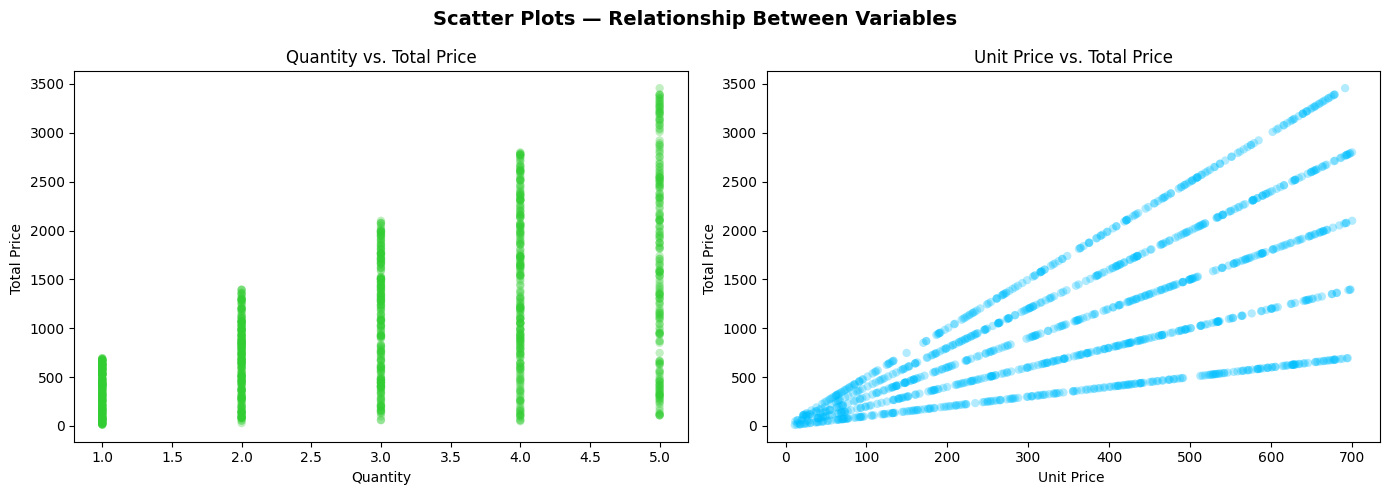

In [65]:
# Scatter: Quantity vs TotalPrice
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['Quantity'], df['TotalPrice'], alpha=0.3, color='limegreen', edgecolors='none')
axes[0].set_title('Quantity vs. Total Price')
axes[0].set_xlabel('Quantity')
axes[0].set_ylabel('Total Price ')

axes[1].scatter(df['UnitPrice'], df['TotalPrice'], alpha=0.3, color='deepskyblue', edgecolors='none')
axes[1].set_title('Unit Price vs. Total Price')
axes[1].set_xlabel('Unit Price ')
axes[1].set_ylabel('Total Price ')

plt.suptitle('Scatter Plots — Relationship Between Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Executive Summary & Business Insights <a id='10-summary'></a>




In [68]:
total_revenue      = df['TotalPrice'].sum()
avg_order_value    = df['TotalPrice'].mean()
median_order_value = df['TotalPrice'].median()
total_orders       = len(df)
cancelled_pct      = (df['OrderStatus'] == 'Cancelled').mean() * 100
returned_pct       = (df['OrderStatus'] == 'Returned').mean() * 100
top_product        = df.groupby('Product')['TotalPrice'].sum().idxmax()
top_referral       = df.groupby('ReferralSource')['TotalPrice'].sum().idxmax()
coupon_avg         = df[df['CouponCode'] != 'No Coupon']['TotalPrice'].mean()
no_coupon_avg      = df[df['CouponCode'] == 'No Coupon']['TotalPrice'].mean()

print("=" * 60)
print("\n  DATASET")
print(f"   Total Orders Analyzed   : {total_orders:,}")
print(f"   Date Range              : {df['Date'].min().date()} to {df['Date'].max().date()}")
print("\n  REVENUE")
print(f"   Top Revenue Product     : {top_product}")
print(f"   Median Order Value      : ${median_order_value:,.2f}")
print(f"   Average Order Value     : ${avg_order_value:,.2f}")
print(f"   Total Revenue           : ${total_revenue:,.2f}")
print("\n  ORDER STATUS")
print(f"   Returned Orders         : {returned_pct:.1f}%")
print(f"   Cancelled Orders        : {cancelled_pct:.1f}%")
print(f"   Loss from cancellations : ${df[df['OrderStatus']=='Cancelled']['TotalPrice'].sum():,.2f}")
print("\n  MARKETING")
print(f"   Top Referral Source     : {top_referral}")
print(f"   Avg Order WITHOUT coupon: ${no_coupon_avg:,.2f}")
print(f"   Avg Order WITH coupon   : ${coupon_avg:,.2f}")
print(f"   Coupon uplift           : ${coupon_avg - no_coupon_avg:,.2f} per order")
print("=" * 60)


  DATASET
   Total Orders Analyzed   : 1,200
   Date Range              : 2023-01-01 to 2025-06-30

  REVENUE
   Top Revenue Product     : Chair
   Median Order Value      : $823.62
   Average Order Value     : $1,053.97
   Total Revenue           : $1,264,761.96

  ORDER STATUS
   Returned Orders         : 20.6%
   Cancelled Orders        : 20.8%
   Loss from cancellations : $276,396.21

  MARKETING
   Top Referral Source     : Instagram
   Avg Order WITHOUT coupon: $1,043.37
   Avg Order WITH coupon   : $1,057.64
   Coupon uplift           : $14.27 per order


## Key Business Findings & Recommendations

### Finding 1 — Revenue Distribution Shows High-Value Outliers

The average order value exceeds the median, suggesting that a relatively small number of expensive orders are increasing the overall average. This indicates that relying only on average order value may not accurately represent most customers. **Recommendation:** Classify customers into low-, medium-, and high-value segments to create more targeted marketing campaigns.

### Finding 2 — Order Cancellations and Returns Reduce Revenue

A noticeable share of orders ends up being cancelled or returned, leading to lost revenue and operational inefficiencies. **Recommendation:** Analyze whether factors such as product type, payment method, or referral source are contributing to higher cancellation and return rates, and address the underlying issues.

### Finding 3 — Coupon Users Generate Higher Purchase Value

Customers who applied coupons placed orders with a higher average value than those who did not use discounts. This suggests that coupons can encourage larger purchases rather than simply attracting bargain seekers. **Recommendation:** Focus coupon campaigns on the referral channels that consistently bring in high-value customers.

### Finding 4 — One Product Category Contributes the Most Revenue

Revenue analysis reveals that a single product category accounts for the largest share of sales compared to the others. **Recommendation:** Maintain sufficient inventory for this category and prioritize it in promotional and marketing activities to maximize revenue.

### Finding 5 — Marketing Performance Differs Across Referral Sources

Referral channels contribute unevenly to total revenue, with some channels delivering significantly better results than others. **Recommendation:** Allocate a larger portion of the marketing budget to the highest-performing referral sources while continuously monitoring their return on investment.

---

*This analysis was completed as part of the DecodeLabs Data Analytics Internship — Project 2 (Exploratory Data Analysis).*
